# Project 4 - Building a Classifier Using the Titanic Dataset
**Author:** Kellie Leopold  
**Date:** November 14, 2025  
**Objective:** Predict a Categorical Target and Evaluate Performance on the Titanic Dataset


## Introduction
This project builds on my previous work with the Titanic dataset, but this time the focus shifts from classification (predicting a category like “survived”) to regression, where the goal is to predict a continuous numeric target. Instead of comparing models on accuracy, precision, or recall, I’m now evaluating how well different regression approaches capture patterns in the data and produce reliable numerical predictions. This shift changes the way the models behave and the types of insights we can get from them.

## Imports

In [641]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # noqa

## Section 1. Load and Explore the Data
Load the titanic dataset directly from the seaborn library.

In [642]:
# Load Titanic dataset from seaborn and verify
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Section 2. Data Exploration and Preparation
Prepare the Titanic data for regression modeling.

* Impute missing values for age using median.
* Drop rows with missing fare.
* Create numeric variables.

In [643]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

titanic = titanic.dropna(subset=['fare'])

titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

## Section 3. Feature Selection and Justification
Define multiple combinations of features to use as inputs to predict fare.

In [644]:
# Case 1. age
X1 = titanic[['age']]
y1 = titanic['fare']

# Case 2. family_size
X2 = titanic[['family_size']]
y2 = titanic['fare']

# Case 3. age, family_size
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

# Case 4. pclass only
X4 = titanic[['pclass']]
y4 = titanic['fare']

In [645]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


**Reflections:**

**Why might these features affect a passenger’s fare?**

Age, family size, and ticket class can all influence fare because they relate to how people traveled. Older passengers and families might buy different types of tickets, and ticket class is directly tied to price. Higher classes usually paid more for better accommodations, while families might choose cheaper options to stay within a budget.

**List all available features:**

* survived
* pclass
* sex
* age
* sibsp
* parch
* fare
* embarked
* class
* who
* adult_male
* deck
* embark_town
* alive
* alone
* family_size

**Which other features could improve predictions and why?**

Features like sex, embarked, or deck could help because they relate to social status, travel route, or accommodation type. These details often influence how much someone paid for their ticket. Anything that reflects a passenger’s living conditions or travel circumstances might strengthen fare predictions.

**How many variables are in your Case 4?**

1 variable.

**Which variable(s) did you choose for Case 4 and why do you feel those could make good inputs?**

For Case 4, I chose pclass because ticket class is directly linked to fare. First-class passengers typically paid much more than second or third class, so pclass is a strong and logical predictor of the price someone paid.

## Section 4. Train a Regression Model (Linear Regression)

### 4.1 Split the Data

In [646]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)

### 4.2 Train and Evaluate Linear Regression Models

In [647]:
# Train models
lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

# Predictions

# Case 1
y_pred_train1 = lr_model1.predict(X1_train)
y_pred_test1  = lr_model1.predict(X1_test)

# Case 2
y_pred_train2 = lr_model2.predict(X2_train)
y_pred_test2  = lr_model2.predict(X2_test)

# Case 3
y_pred_train3 = lr_model3.predict(X3_train)
y_pred_test3  = lr_model3.predict(X3_test)

# Case 4
y_pred_train4 = lr_model4.predict(X4_train)
y_pred_test4  = lr_model4.predict(X4_test)

### 4.3 Report Performance

In [648]:
# Case 1
print("Case 1: Training R²:", r2_score(y1_train, y_pred_train1))
print("Case 1: Test R²:", r2_score(y1_test, y_pred_test1))
print("Case 1: Test RMSE:", np.sqrt(mean_squared_error(y1_test, y_pred_test1)))
print("Case 1: Test MAE:", mean_absolute_error(y1_test, y_pred_test1))
print()

# Case 2
print("Case 2: Training R²:", r2_score(y2_train, y_pred_train2))
print("Case 2: Test R²:", r2_score(y2_test, y_pred_test2))
print("Case 2: Test RMSE:", np.sqrt(mean_squared_error(y2_test, y_pred_test2)))
print("Case 2: Test MAE:", mean_absolute_error(y2_test, y_pred_test2))
print()

# Case 3
print("Case 3: Training R²:", r2_score(y3_train, y_pred_train3))
print("Case 3: Test R²:", r2_score(y3_test, y_pred_test3))
print("Case 3: Test RMSE:", np.sqrt(mean_squared_error(y3_test, y_pred_test3)))
print("Case 3: Test MAE:", mean_absolute_error(y3_test, y_pred_test3))
print()

# Case 4
print("Case 4: Training R²:", r2_score(y4_train, y_pred_train4))
print("Case 4: Test R²:", r2_score(y4_test, y_pred_test4))
print("Case 4: Test RMSE:", np.sqrt(mean_squared_error(y4_test, y_pred_test4)))
print("Case 4: Test MAE:", mean_absolute_error(y4_test, y_pred_test4))

Case 1: Training R²: 0.009950688019452314
Case 1: Test R²: 0.0034163395508415295
Case 1: Test RMSE: 37.97164180172938
Case 1: Test MAE: 25.28637293162364

Case 2: Training R²: 0.049915792364760736
Case 2: Test R²: 0.022231186110131973
Case 2: Test RMSE: 37.6114940041967
Case 2: Test MAE: 25.02534815941641

Case 3: Training R²: 0.07347466201590014
Case 3: Test R²: 0.049784832763073106
Case 3: Test RMSE: 37.0777586646559
Case 3: Test MAE: 24.284935030470688

Case 4: Training R²: 0.3005588037487471
Case 4: Test R²: 0.3016017234169923
Case 4: Test RMSE: 31.7873316928033
Case 4: Test MAE: 20.653703671484056


**Reflections:**

Train vs Test:

* Cases 1–3: R² is super low, so the models barely explain the fare.
* Case 4: R² around 0.3, way better and similar on train and test.

Overfit or Underfit:

* Case 1: Underfit - age alone doesn’t explain fare.
* Case 2: Underfit – family size helps a bit but still weak.
* Case 3: Underfit – age + family size improves slightly, still too simple.
* Case 4: Pretty good – pclass predicts fare reasonably well, train/test similar.

Adding Age:

* Helps a little in Case 3.
* Older or younger passengers may buy different types of tickets, but age isn’t a strong predictor alone.

Worst Case:

* Case 1: lowest R², highest errors.
* More data might help a bit, but age alone won’t make a big difference.

Best Case:

* Case 4: highest R², lowest errors.
* Adding more data could improve it further because pclass is a strong predictor.

## Section 5. Compare Alternative Models
Take the best-performing case and explore other regression models.

In [649]:
# X4 and y4 are already defined from Case 4
# Split into train/test
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.3, random_state=42)

### 5.1 Ridge Regression (L2 penalty)

In [650]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X4_train, y4_train)
y_pred_ridge = ridge_model.predict(X4_test)

### 5.2 Elastic Net (L1 + L2 combined)

In [651]:
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic_model.fit(X4_train, y4_train)
y_pred_elastic = elastic_model.predict(X4_test)

### 5.3 Polynomial Regression

In [652]:
# Degree 3 polynomial
poly = PolynomialFeatures(degree=3)
X4_train_poly = poly.fit_transform(X4_train)
X4_test_poly = poly.transform(X4_test)

# Fit linear regression on polynomial features
poly_model = LinearRegression()
poly_model.fit(X4_train_poly, y4_train)

# Predictions
y_pred_poly = poly_model.predict(X4_test_poly)

### 5.4 Visualize Polynomial Fit

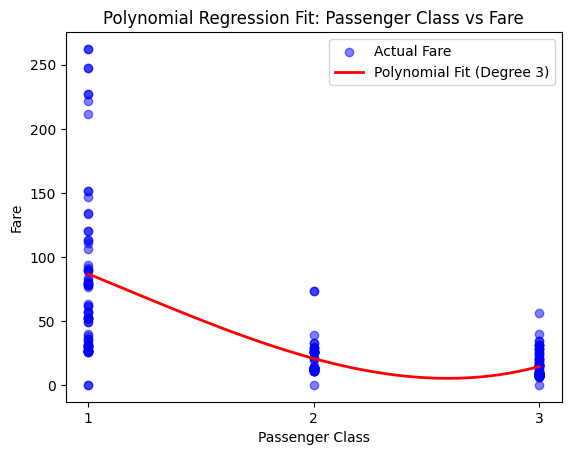

In [653]:
# Create smooth X values
X_plot = np.linspace(X4['pclass'].min(), X4['pclass'].max(), 100).reshape(-1, 1)
X_plot = pd.DataFrame(X_plot, columns=['pclass'])  # fix column names

# Predict using the polynomial model
y_plot = poly_model.predict(poly.transform(X_plot))

# Plot
plt.scatter(X4_test['pclass'], y4_test, color='blue', alpha=0.5, label='Actual Fare')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Polynomial Fit (Degree 3)')
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title("Polynomial Regression Fit: Passenger Class vs Fare")
plt.xticks([1, 2, 3])
plt.legend()
plt.show()

### 5.4 Reflections

* Patterns captured: Polynomial regression can capture nonlinear trends (e.g., 1st class pays much more than 2nd/3rd).
* Where it performs well/poorly: Works best where there are extreme fares (1st class). Poor fit for middle or outlier fares.
* Comparison to linear regression: Slightly better at capturing nonlinearity, but overfitting can happen with higher-degree polynomials.
* Best fit: Around the most extreme fares, cubic curve follows trend better than straight line.

### 5.5 Compare All Models

In [654]:
# Function to compute metrics
def get_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "Model": name,
        "R²": r2_score(y_true, y_pred),
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_true, y_pred)
    }

# Collect metrics for all models
metrics_list = [
    get_metrics("Linear", y4_test, lr_model4.predict(X4_test)),
    get_metrics("Ridge", y4_test, y_pred_ridge),
    get_metrics("ElasticNet", y4_test, y_pred_elastic),
    get_metrics("Polynomial", y4_test, y_pred_poly)
]

# Create table
metrics_df = pd.DataFrame(metrics_list)
metrics_df[["R²", "RMSE", "MAE"]] = metrics_df[["R²", "RMSE", "MAE"]].round(3)
metrics_df

,Model,R²,RMSE,MAE
0,Linear,0.360,37.146,21.149
1,Ridge,0.362,37.090,21.198
2,ElasticNet,0.353,37.367,21.513
3,Polynomial,0.402,35.912,20.137


### 5.6 Visualize Higher Order Polynomial

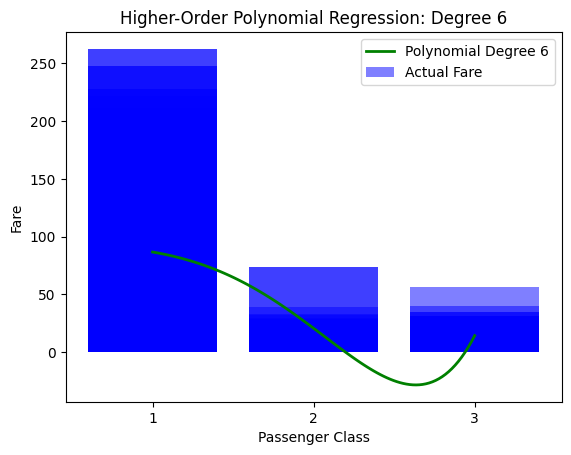

In [655]:
# Higher degree polynomial (degree = 6)
degree = 6
poly_high = PolynomialFeatures(degree=degree)
X4_train_poly_high = poly_high.fit_transform(X4_train)
X4_test_poly_high = poly_high.transform(X4_test)

# Fit regression
poly_high_model = LinearRegression()
poly_high_model.fit(X4_train_poly_high, y4_train)

# Smooth curve for plotting
X_plot = np.linspace(X4['pclass'].min(), X4['pclass'].max(), 100).reshape(-1, 1)
X_plot = pd.DataFrame(X_plot, columns=['pclass'])  # make it a DataFrame to match feature names
y_plot_high = poly_high_model.predict(poly_high.transform(X_plot))

# Plot
plt.bar(X4_test['pclass'], y4_test, color='blue', alpha=0.5, label='Actual Fare')
plt.plot(X_plot, y_plot_high, color='green', linewidth=2, label=f'Polynomial Degree {degree}')
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title(f"Higher-Order Polynomial Regression: Degree {degree}")
plt.xticks([1, 2, 3])
plt.legend()
plt.show()
plt.show()